# 03. 評価

学習済みモデルを評価し、性能を分析します。

## 処理フロー
1. 学習済みモデルのロード
2. テストデータでの評価
3. 混同行列の作成
4. ラベルごとの精度分析

## エンティティ
- **疾患（Disease）**: 🟠 薄いオレンジ (#ffe6b3)
- **薬剤（Chemical）**: 🔵 薄い青 (#b3d9ff)

## 1. ライブラリのインポート

In [1]:
import torch
from transformers import AutoTokenizer, AutoModelForTokenClassification
from datasets import load_from_disk
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from collections import Counter
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print(f"PyTorch: {torch.__version__}")
print(f"CUDA利用可: {torch.cuda.is_available()}")

PyTorch: 2.5.1+cu121
CUDA利用可: True


## 2. ラベル定義

In [2]:
# ラベル定義（bigbio/bc5cdr 正しい順序）
label_list = ['O', 'B-Chemical', 'I-Chemical', 'B-Disease', 'I-Disease']
num_labels = len(label_list)

# id2label と label2id
id2label = {i: label for i, label in enumerate(label_list)}
label2id = {label: i for i, label in enumerate(label_list)}

print("=== ラベル定義 ===")
for i, label in enumerate(label_list):
    icon = ''
    if 'Chemical' in label:
        icon = '🔵'
    elif 'Disease' in label:
        icon = '🟠'
    print(f"{i}: {label} {icon}")

print(f"\nラベル数: {num_labels}")

=== ラベル定義 ===
0: O 
1: B-Chemical 🔵
2: I-Chemical 🔵
3: B-Disease 🟠
4: I-Disease 🟠

ラベル数: 5


## 3. 学習済みモデルのロード

In [3]:
# 学習済みモデルをロード
model_path = "../results/biobert-ner-bc5cdr"

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForTokenClassification.from_pretrained(model_path)

# GPUがあれば使用
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# モデルのconfigからラベルを確認
model_labels = model.config.id2label

print(f"モデル: {model_path}")
print(f"デバイス: {device}")
print(f"\nモデルのラベル定義:")
for i, label in model_labels.items():
    print(f"  {i}: {label}")

モデル: ../results/biobert-ner-bc5cdr
デバイス: cuda

モデルのラベル定義:
  0: O
  1: B-Chemical
  2: I-Chemical
  3: B-Disease
  4: I-Disease


## 4. テストデータのロード

In [4]:
# 前処理済みデータをロード
tokenized_datasets = load_from_disk("processed_bc5cdr")

test_dataset = tokenized_datasets["test"]

print(f"テストデータサイズ: {len(test_dataset)}")
print(f"特徴量: {list(test_dataset.features.keys())}")

テストデータサイズ: 1000
特徴量: ['input_ids', 'token_type_ids', 'attention_mask', 'labels']


## 5. 推論実行

In [5]:
# Trainerを使って推論実行
from transformers import Trainer, DataCollatorForTokenClassification

# データコレーター
data_collator = DataCollatorForTokenClassification(tokenizer)

# Trainerを初期化
trainer = Trainer(
    model=model,
    data_collator=data_collator
)

# 推論実行
print("推論を実行中...")
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

print(f"推論完了: {len(preds)} サンプル")

推論を実行中...


推論完了: 1000 サンプル


## 6. 評価指標の計算

In [6]:
# -100を除外して評価
true_predictions = [
    [model_labels[p] for (p, l) in zip(pred, label) if l != -100]
    for pred, label in zip(preds, labels)
]
true_labels = [
    [model_labels[l] for (p, l) in zip(pred, label) if l != -100]
    for pred, label in zip(preds, labels)
]

# flatten
flat_predictions = [p for preds in true_predictions for p in preds]
flat_labels = [l for labels in true_labels for l in labels]

# classification report
print("=== Classification Report ===")
report = classification_report(
    flat_labels, 
    flat_predictions, 
    target_names=list(model_labels.values()),
    digits=4
)
print(report)

# 全体F1スコア
from sklearn.metrics import f1_score
f1_micro = f1_score(flat_labels, flat_predictions, average='micro')
f1_macro = f1_score(flat_labels, flat_predictions, average='macro')
print(f"\n=== 全体F1スコア ===")
print(f"F1 (micro): {f1_micro:.4f}")
print(f"F1 (macro): {f1_macro:.4f}")

=== Classification Report ===
              precision    recall  f1-score   support

           O     0.9054    0.9422    0.9234      5140
  B-Chemical     0.8080    0.8723    0.8389      4379
  I-Chemical     0.8109    0.8120    0.8115       750
   B-Disease     0.7319    0.8402    0.7824      2460
   I-Disease     0.9915    0.9827    0.9871    104079

    accuracy                         0.9727    116808
   macro avg     0.8495    0.8899    0.8687    116808
weighted avg     0.9742    0.9727    0.9733    116808


=== 全体F1スコア ===
F1 (micro): 0.9727
F1 (macro): 0.8687


## 7. 混同行列の作成

C:\Users\hello\AppData\Local\Temp\ipykernel_13524\2377451755.py:23: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hello\AppData\Local\Temp\ipykernel_13524\2377451755.py:23: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hello\AppData\Local\Temp\ipykernel_13524\2377451755.py:24: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('../results/confusion_matrix.png', dpi=150, bbox_inches='tight')
C:\Users\hello\AppData\Local\Temp\ipykernel_13524\2377451755.py:24: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('../results/confusion_matrix.png', dpi=150, bbox_inches='tight')
C:\Users\hello\Desktop\project\PyTorch_Proj\.conda\env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu San

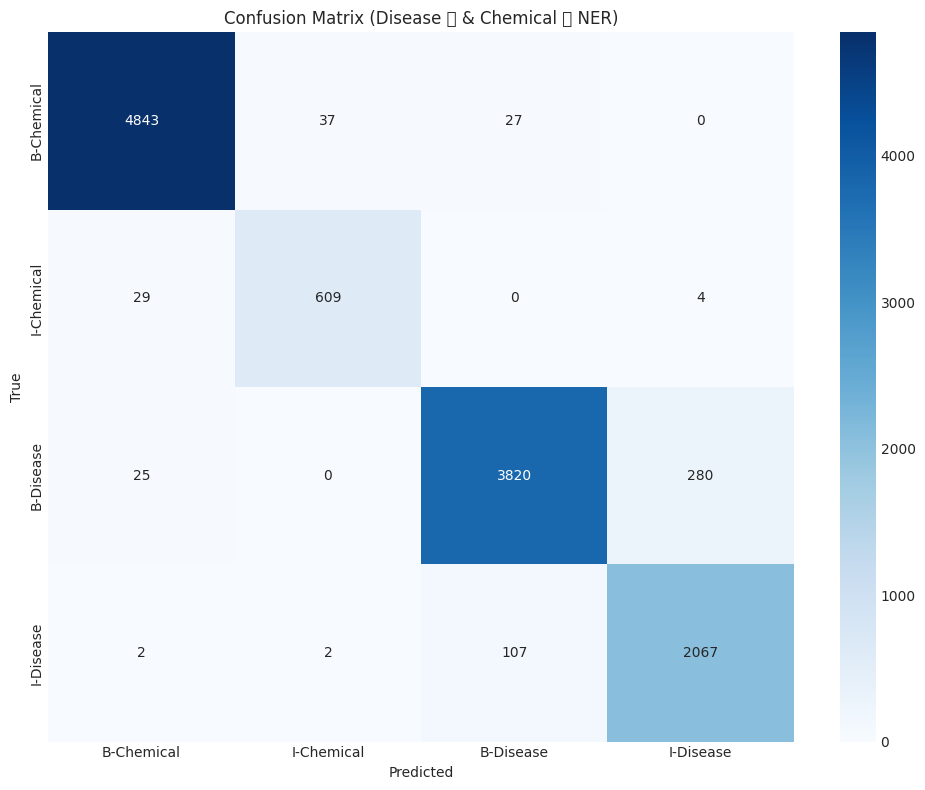

混同行列を保存しました: ../results/confusion_matrix.png


In [7]:
# 混同行列（Oを除く）
target_names = [label for label in model_labels.values() if label != 'O']

# フィルタリング
predictions_filtered = []
labels_filtered = []

for p_list, l_list in zip(true_predictions, true_labels):
    for p, l in zip(p_list, l_list):
        if l != 'O':
            predictions_filtered.append(p)
            labels_filtered.append(l)

cm = confusion_matrix(labels_filtered, predictions_filtered, labels=target_names)

# 混同行列を可視化
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix (Disease 🟠 & Chemical 🔵 NER)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig('../results/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("混同行列を保存しました: ../results/confusion_matrix.png")

## 8. ラベルごとの精度

In [8]:
# ラベルごとのF1スコア
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    flat_labels, flat_predictions, labels=list(model_labels.values()), average=None
)

# DataFrameで表示
results_df = pd.DataFrame({
    'Label': list(model_labels.values()),
    'Precision': precision,
    'Recall': recall,
    'F1': f1,
    'Support': support
})

# O（その他）を除いて表示
results_df_filtered = results_df[results_df['Label'] != 'O']
print("=== ラベルごとの精度 ===")
print(results_df_filtered.to_string(index=False))

# 色分けして表示
print("\n=== 色分け対応 ===")
for _, row in results_df_filtered.iterrows():
    if 'Disease' in row['Label']:
        color = '🟠'
    elif 'Chemical' in row['Label']:
        color = '🔵'
    else:
        color = ''
    print(f"{row['Label']:12} {color} F1: {row['F1']:.4f}")

=== ラベルごとの精度 ===
     Label  Precision   Recall       F1  Support
B-Chemical   0.905403 0.942218 0.923444     5140
I-Chemical   0.810919 0.812000 0.811459      750
 B-Disease   0.807953 0.872345 0.838915     4379
 I-Disease   0.731941 0.840244 0.782362     2460

=== 色分け対応 ===
B-Chemical   🔵 F1: 0.9234
I-Chemical   🔵 F1: 0.8115
B-Disease    🟠 F1: 0.8389
I-Disease    🟠 F1: 0.7824


C:\Users\hello\AppData\Local\Temp\ipykernel_13524\1081369747.py:19: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hello\AppData\Local\Temp\ipykernel_13524\1081369747.py:19: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hello\AppData\Local\Temp\ipykernel_13524\1081369747.py:20: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('../results/f1_score_by_label.png', dpi=150, bbox_inches='tight')
C:\Users\hello\AppData\Local\Temp\ipykernel_13524\1081369747.py:20: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('../results/f1_score_by_label.png', dpi=150, bbox_inches='tight')
C:\Users\hello\Desktop\project\PyTorch_Proj\.conda\env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu S

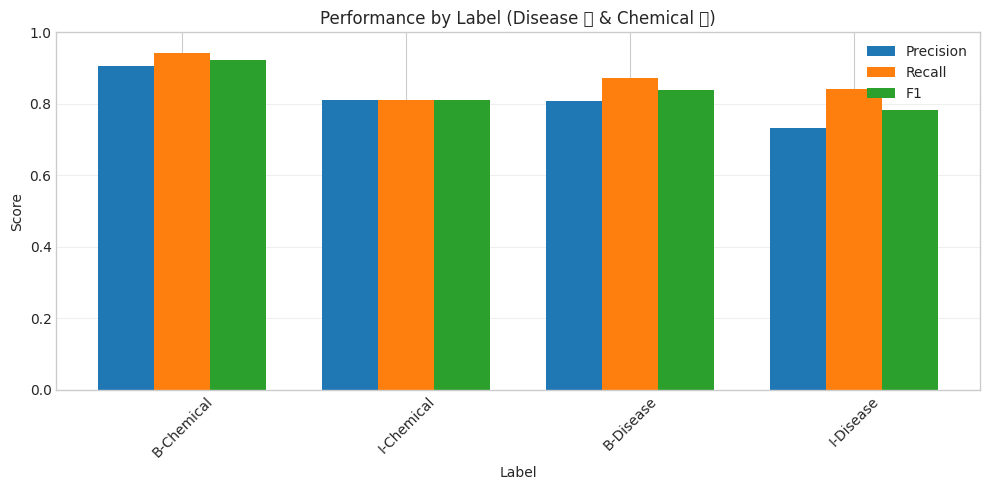


F1スコアグラフを保存しました: ../results/f1_score_by_label.png


In [9]:
# グラフで表示
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df_filtered))
width = 0.25

ax.bar(x - width, results_df_filtered['Precision'], width, label='Precision')
ax.bar(x, results_df_filtered['Recall'], width, label='Recall')
ax.bar(x + width, results_df_filtered['F1'], width, label='F1')

ax.set_xlabel('Label')
ax.set_ylabel('Score')
ax.set_title('Performance by Label (Disease 🟠 & Chemical 🔵)')
ax.set_xticks(x)
ax.set_xticklabels(results_df_filtered['Label'], rotation=45)
ax.legend()
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/f1_score_by_label.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nF1スコアグラフを保存しました: ../results/f1_score_by_label.png")

## 9. エンティティ別の集計

In [10]:
# エンティティタイプ別に集計
def aggregate_entity_type(labels, predictions, entity_type):
    """特定のエンティティタイプのF1を計算"""
    # B-XXX と I-XXX をまとめる
    true_labels_filtered = []
    pred_labels_filtered = []
    
    for t, p in zip(labels, predictions):
        if entity_type in t:
            true_labels_filtered.append(entity_type)
            pred_labels_filtered.append(entity_type if entity_type in p else 'O')
        elif entity_type in p:
            # 誤検知
            true_labels_filtered.append('O')
            pred_labels_filtered.append(entity_type)
    
    if len(true_labels_filtered) == 0:
        return {'precision': 0, 'recall': 0, 'f1': 0, 'support': 0}
    
    from sklearn.metrics import precision_recall_fscore_support
    precision, recall, f1, support = precision_recall_fscore_support(
        true_labels_filtered, pred_labels_filtered, labels=[entity_type, 'O'], average=None
    )
    
    return {
        'precision': precision[0],
        'recall': recall[0],
        'f1': f1[0],
        'support': support[0]
    }

# Chemical と Disease を集計
chemical_metrics = aggregate_entity_type(flat_labels, flat_predictions, 'Chemical')
disease_metrics = aggregate_entity_type(flat_labels, flat_predictions, 'Disease')

print("=== エンティティタイプ別の精度 ===")
print(f"{'Chemical 🔵':20} P: {chemical_metrics['precision']:.4f}  R: {chemical_metrics['recall']:.4f}  F1: {chemical_metrics['f1']:.4f}")
print(f"{'Disease 🟠':20} P: {disease_metrics['precision']:.4f}  R: {disease_metrics['recall']:.4f}  F1: {disease_metrics['f1']:.4f}")

=== エンティティタイプ別の精度 ===
Chemical 🔵           P: 0.9046  R: 0.9368  F1: 0.9204
Disease 🟠            P: 0.8308  R: 0.9174  F1: 0.8719


## 10. エラー分析

In [11]:
# エラーサンプルを収集
errors = []

for i in range(min(100, len(true_labels))):
    for j in range(len(true_labels[i])):
        if true_labels[i][j] != 'O' and true_labels[i][j] != true_predictions[i][j]:
            errors.append({
                'true_label': true_labels[i][j],
                'predicted': true_predictions[i][j]
            })

# エンティティの総数を計算
total_entities = sum(1 for labels in true_labels for l in labels if l != 'O')

print(f"エラー数: {len(errors)}")
if total_entities > 0:
    print(f"エラー率: {len(errors) / total_entities:.4f}")
else:
    print("エンティティがありません")

エラー数: 158
エラー率: 0.0124


## 11. 結果の保存

In [12]:
# 評価結果を保存
eval_results = {
    'f1_micro': float(f1_micro),
    'f1_macro': float(f1_macro),
    'chemical_f1': float(chemical_metrics['f1']),
    'disease_f1': float(disease_metrics['f1']),
    'classification_report': report,
    'num_test_samples': int(len(test_dataset)),
    'num_errors': int(len(errors))
}

import json
with open('../results/evaluation_results.json', 'w', encoding='utf-8') as f:
    json.dump(eval_results, f, ensure_ascii=False, indent=2)

print("評価結果を保存しました: ../results/evaluation_results.json")
print("\n次のステップ: 04_demo.ipynb")

評価結果を保存しました: ../results/evaluation_results.json

次のステップ: 04_demo.ipynb
